In [1]:
# TP2 : 1- Profiling systématique des données récupérées au TP 1 : distributions, cardinalités, doublons de codes-barres,
# incohérences d'unités, valeurs impossibles (sucres > 100 g/100 g, énergies nulles…)

import pyarrow.parquet as pq
import pandas as pd
from tabulate import tabulate

parquet_file_path = "../../food_france.parquet"
# Chargement du Parquet : Le parcourir en mode streaming (Une lecture en flux continu) :
parquet_file = pq.ParquetFile(parquet_file_path)

data_frame_grade = pd.read_parquet(parquet_file_path, columns=['nutriscore_grade'])
grade_distribution = data_frame_grade['nutriscore_grade'].value_counts()
grade_distribution_percent = data_frame_grade['nutriscore_grade'].value_counts(normalize=True) * 100


 # --- AFFICHAGE DU TABLEAU DES DONNEES ---
# Affichage du tableau avec des bordures en grille
# Fusionner et trier le tableau (de A à E)
dist_table = pd.concat([grade_distribution, grade_distribution_percent], axis=1)
dist_table.columns = ['Nombre de produits par Nutri-Score', 'Pourcentage (%)']
dist_table = dist_table.sort_index()

for_display_table = tabulate(
    dist_table, 
    headers='keys', 
    tablefmt='fancy_grid',  # Style de bordure
    floatfmt='.2f',         # Arrondir les pourcentages à 2 décimales
    numalign='right'        # Aligner les chiffres à droite
)

# 5. Afficher le résultat
print(for_display_table)

╒════════════════════╤══════════════════════════════════════╤═══════════════════╕
│ nutriscore_grade   │   Nombre de produits par Nutri-Score │   Pourcentage (%) │
╞════════════════════╪══════════════════════════════════════╪═══════════════════╡
│ a                  │                             63114.00 │             13.61 │
├────────────────────┼──────────────────────────────────────┼───────────────────┤
│ b                  │                             49567.00 │             10.69 │
├────────────────────┼──────────────────────────────────────┼───────────────────┤
│ c                  │                             96394.00 │             20.79 │
├────────────────────┼──────────────────────────────────────┼───────────────────┤
│ d                  │                            122532.00 │             26.42 │
├────────────────────┼──────────────────────────────────────┼───────────────────┤
│ e                  │                            132145.00 │             28.49 │
╘═══════════════

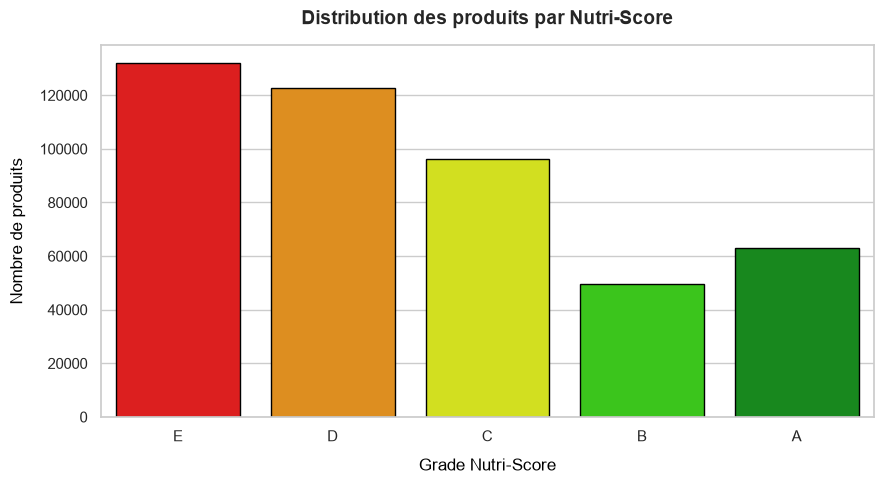

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

grade_values = pd.Series(data_frame_grade['nutriscore_grade'])
upper_grade_values = grade_values.str.upper()

nutriscore_colors = ["#fb0000", "#fc9300", "#eeff00", "#29e100", "#059b0d"]

# Dessiner le graphique de distribution  
ax = sns.countplot(
    data=data_frame_grade,
    edgecolor="black", 
    linewidth=1,
    x=upper_grade_values, 
    order=upper_grade_values, 
    palette=nutriscore_colors,
    hue='nutriscore_grade', # Évite un avertissement de Seaborn
    legend=False
)


plt.title('Distribution des produits par Nutri-Score', fontsize=14, weight='bold', pad=15)
plt.xlabel('Grade Nutri-Score', fontsize=12, labelpad=10, color='black')
plt.ylabel('Nombre de produits', fontsize=12, labelpad=10, color='black')

# Ajuster les marges et afficher le graphique
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np


# Dictionnaire pour stocker toutes les valeurs uniques globales
unique_sets = {}

# Fonction de nettoyage pour gérer TOUS les types non hachables (listes, ndarray, dictionnaires)
def make_hashable(val):
    if isinstance(val, (list, np.ndarray, tuple)):
        return str(list(val))  # Convertit le tableau en chaîne textuelle standard '[val1, val2]'
    elif isinstance(val, dict):
        return str(val)
    return val

# Parcourir le fichier par morceaux (Row Groups) pour économiser la RAM
for i in range(parquet_file.num_row_groups):
    print(f"Traitement du groupe {i+1}/{parquet_file.num_row_groups}...")
    
    # Charger un seul morceau en DataFrame Pandas
    data_frame_chunk = parquet_file.read_row_group(i).to_pandas()
    
    for col in data_frame_chunk.columns:
        if col not in unique_sets:
            unique_sets[col] = set()
            
        # Éliminer les valeurs manquantes
        series_clean = data_frame_chunk[col].dropna()
        
        # Transformer chaque élément pour s'assurer qu'il soit hachable (String, Int, Float...)
        # On utilise une boucle Python classique pour contourner le moteur de hash de Pandas
        for item in series_clean:
            unique_sets[col].add(make_hashable(item))

# Calculer la taille de chaque ensemble (la cardinalité finale)
cardinalities = {col: len(values) for col, values in unique_sets.items()}

print("\n--- CARDINALITÉS DES COLONNES COMPLÈTES ---")
for col, card in cardinalities.items():
    print(f"{col}: {card}")

Le fichier contient 1 groupes de lignes.
Traitement du groupe 1/1...

--- CARDINALITÉS DES COLONNES COMPLÈTES ---
code: 463747
product_name: 330030
countries_tags: 3389
quantity: 20233
brands_tags: 56704
brands: 66839
categories: 96752
categories_tags: 76796
nutriscore_grade: 5
nutriscore_score: 70


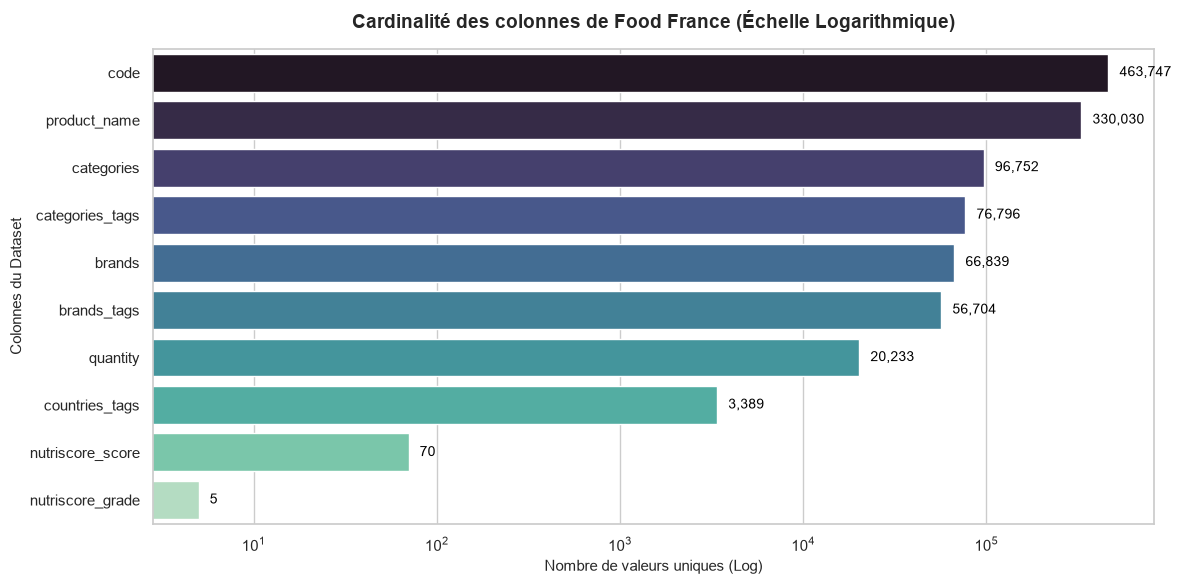

In [30]:
data_frame_plot = pd.DataFrame(cardinalities.items(), columns=["Colonne", "Cardinalité"])
data_frame_plot = data_frame_plot.sort_values(by="Cardinalité", ascending=False)

# 3. Configuration du style de graphique
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 4. Création du diagramme à barres horizontales
# Une palette de couleurs dégradée met en valeur l'importance des cardinalités
ax = sns.barplot(
    x="Cardinalité", 
    y="Colonne", 
    data=data_frame_plot, 
    palette="mako", 
    hue="Colonne", 
    legend=False
)

# 5. PASSAGE EN ÉCHELLE LOGARITHMIQUE (Crucial pour Open Food Facts !)
ax.set_xscale("log")

# 6. Personnalisation des axes et du titre
plt.title("Cardinalité des colonnes de Food France (Échelle Logarithmique)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Nombre de valeurs uniques (Log)", fontsize=11)
plt.ylabel("Colonnes du Dataset", fontsize=11)

# Ajouter la valeur brute textuelle au bout de chaque barre pour faciliter la lecture
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(
            width * 1.15, # Positionner le texte légèrement après la barre
            p.get_y() + p.get_height() / 2, 
            f'{int(width):,}', 
            va='center', 
            fontsize=10, 
            color='black'
        )

# Ajustement des marges pour éviter que le texte soit coupé
plt.tight_layout()
plt.show()

In [33]:
# Doublons codes-barres :
duplicates_codes = parquet_file.metadata.num_rows - cardinalities['code']
print(f"Le nombre des doublons de codes-barres = {duplicates_codes}")

Le nombre des doublons de codes-barres = 5
